# 7-2 Why Do We Require Data Pre Processing_With an Example Dataset

# 7-3 Handling Missing Values_Titanic Dataset Part 1

In [4]:
import pandas as pd
titanic_path = "/content/sample_data/Titanic-Dataset.csv"
df_titanic = pd.read_csv(titanic_path)
df_titanic.head(10)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
5,6,0,3,"Moran, Mr. James",male,NaN,0,0,330877,8.4583,NaN,Q
6,7,0,1,"McCarthy, Mr. Timothy J",male,54.0,0,0,17463,51.8625,E46,S
7,8,0,3,"Palsson, Master. Gosta Leonard",male,2.0,3,1,349909,21.0750,NaN,S
8,9,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27.0,0,2,347742,11.1333,NaN,S
9,10,1,2,"Nasser, Mrs. Nicholas (Adele Achem)",female,14.0,1,0,237736,30.0708,NaN,C


In [5]:
df_titanic.shape

(891, 12)

In [6]:
print("Unique Values per Column:")
df_titanic.nunique()

Unique Values per Column:


,0
PassengerId,891
Survived,2
Pclass,3
Name,891
Sex,2
Age,88
SibSp,7
Parch,7
Ticket,681
Fare,248


In [7]:
print("Missing Values per column:")
df_titanic.isnull().sum()

Missing Values per column:


,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


Distribution of Age:


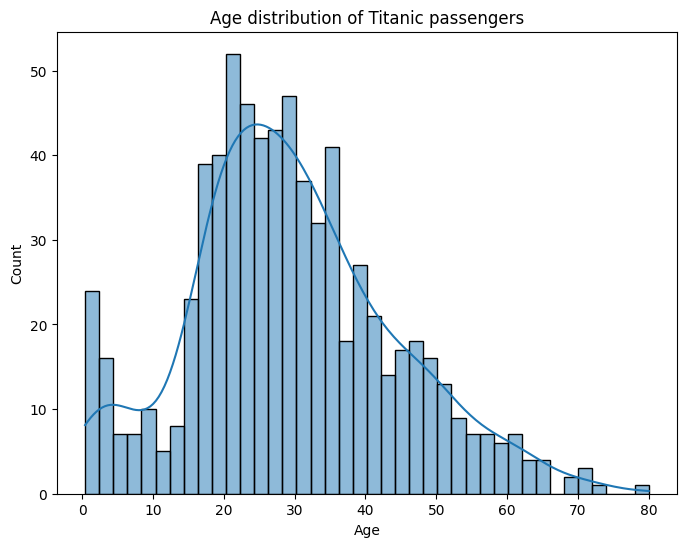

In [8]:
print("Distribution of Age:")
import seaborn as sns
import matplotlib.pyplot as plt
plt.figure(figsize=(8,6))
sns.histplot(df_titanic["Age"], kde = True, bins = 40)
plt.title("Age distribution of Titanic passengers")
plt.xlabel("Age")
plt.ylabel("Count")
plt.show()

#Here we will use median as the feature values are right skewed




Distribution of Embarked Column:


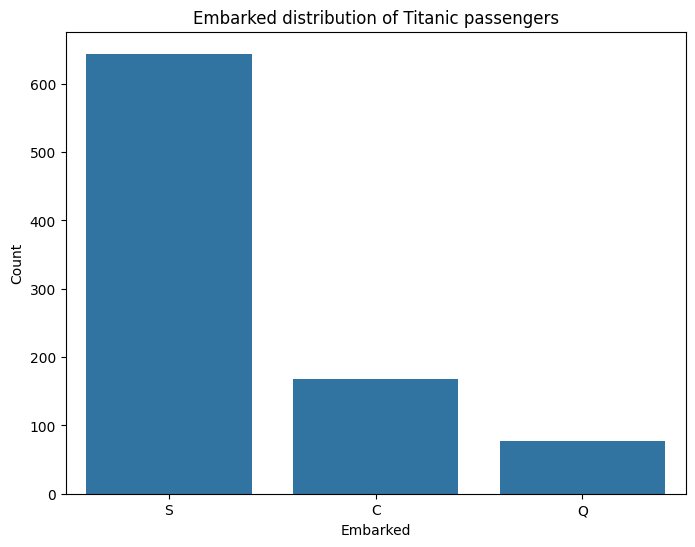

In [9]:
print("Distribution of Embarked Column:")
import seaborn as sns
import matplotlib.pyplot as plt
plt.figure(figsize=(8,6))
sns.countplot(data = df_titanic, x = "Embarked")
plt.title("Embarked distribution of Titanic passengers")
plt.xlabel("Embarked")
plt.ylabel("Count")
plt.show()

#Here we will use mode


In [10]:
#Handling numeric missing value: Age
age_median = df_titanic["Age"].median()
df_titanic["Age"] = df_titanic["Age"].fillna(age_median)
df_titanic.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,0
SibSp,0
Parch,0
Ticket,0
Fare,0


In [11]:
#Handle Categorical missing values: Embarked
embarked_mode = df_titanic["Embarked"].mode()[0]
df_titanic['Embarked'] = df_titanic['Embarked'].fillna(embarked_mode)
df_titanic.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,0
SibSp,0
Parch,0
Ticket,0
Fare,0


In [12]:
#Drop Cabin(more then 70% missing values)
df_titanic = df_titanic.drop(columns= ["Cabin"])
df_titanic.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,0
SibSp,0
Parch,0
Ticket,0
Fare,0


# 7-5 Encoding Categorical Variables or Features

In [13]:
from sklearn.preprocessing import LabelEncoder

# load data

heart_path = "/content/sample_data/heart.csv"
df_heart = pd.read_csv(heart_path)

print(df_heart.head(10))
print(df_heart.dtypes)

   Age Sex ChestPainType  RestingBP  Cholesterol  FastingBS RestingECG  MaxHR  \
0   40   M           ATA        140          289          0     Normal    172   
1   49   F           NAP        160          180          0     Normal    156   
2   37   M           ATA        130          283          0         ST     98   
3   48   F           ASY        138          214          0     Normal    108   
4   54   M           NAP        150          195          0     Normal    122   
5   39   M           NAP        120          339          0     Normal    170   
6   45   F           ATA        130          237          0     Normal    170   
7   54   M           ATA        110          208          0     Normal    142   
8   37   M           ASY        140          207          0     Normal    130   
9   48   F           ATA        120          284          0     Normal    120   

  ExerciseAngina  Oldpeak ST_Slope  HeartDisease  
0              N      0.0       Up             0  
1     

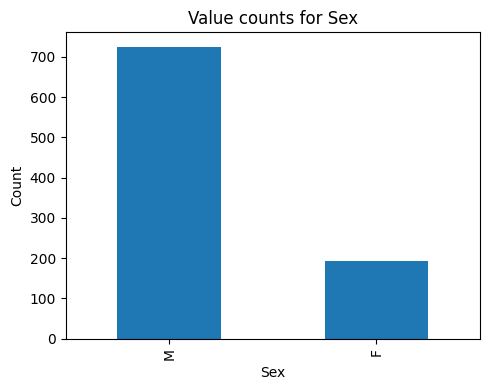

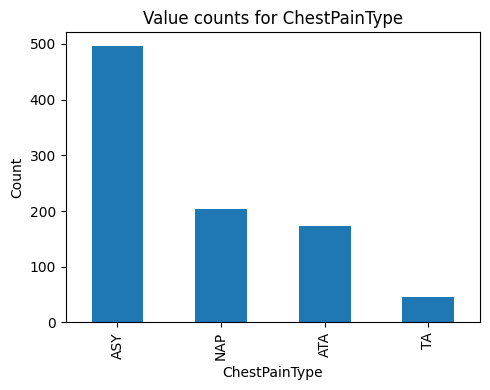

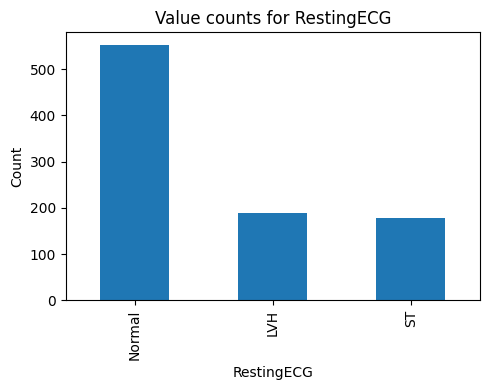

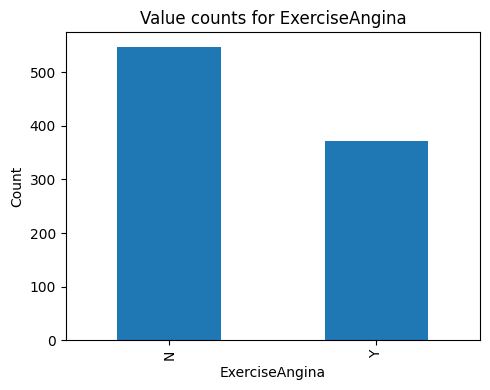

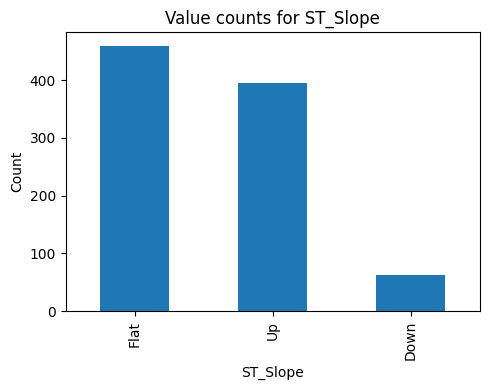

In [14]:
#Categorical Feature Exploration
cat_cols = ["Sex", "ChestPainType", "RestingECG", "ExerciseAngina", "ST_Slope"]
for c in cat_cols:
  plt.figure(figsize=(5,4))
  df_heart[c].value_counts().plot(kind = "bar")
  plt.title(f"Value counts for {c}")
  plt.ylabel("Count")
  plt.tight_layout()
  plt.show()

In [15]:
#Label Encoding for binary categorical columns -> Sex and ExerciseAngina
le = LabelEncoder()
df_heart["Sex"] = le.fit_transform(df_heart["Sex"])
df_heart["ExerciseAngina"] = le.fit_transform(df_heart["ExerciseAngina"])
df_heart.head(10)


,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,1,ATA,140,289,0,Normal,172,0,0.0,Up,0
1,49,0,NAP,160,180,0,Normal,156,0,1.0,Flat,1
2,37,1,ATA,130,283,0,ST,98,0,0.0,Up,0
3,48,0,ASY,138,214,0,Normal,108,1,1.5,Flat,1
4,54,1,NAP,150,195,0,Normal,122,0,0.0,Up,0
5,39,1,NAP,120,339,0,Normal,170,0,0.0,Up,0
6,45,0,ATA,130,237,0,Normal,170,0,0.0,Up,0
7,54,1,ATA,110,208,0,Normal,142,0,0.0,Up,0
8,37,1,ASY,140,207,0,Normal,130,1,1.5,Flat,1
9,48,0,ATA,120,284,0,Normal,120,0,0.0,Up,0


In [16]:
#OneHot Encoding for nominal categorical columns
cat_cols = ["ChestPainType", "RestingECG", "ST_Slope"]
df_heart_encoded = pd.get_dummies(
    df_heart,
    columns= cat_cols,
    dtype=int

)

df_heart_encoded.head(10)

,Age,Sex,RestingBP,Cholesterol,FastingBS,MaxHR,ExerciseAngina,Oldpeak,HeartDisease,ChestPainType_ASY,ChestPainType_ATA,ChestPainType_NAP,ChestPainType_TA,RestingECG_LVH,RestingECG_Normal,RestingECG_ST,ST_Slope_Down,ST_Slope_Flat,ST_Slope_Up
0,40,1,140,289,0,172,0,0.0,0,0,1,0,0,0,1,0,0,0,1
1,49,0,160,180,0,156,0,1.0,1,0,0,1,0,0,1,0,0,1,0
2,37,1,130,283,0,98,0,0.0,0,0,1,0,0,0,0,1,0,0,1
3,48,0,138,214,0,108,1,1.5,1,1,0,0,0,0,1,0,0,1,0
4,54,1,150,195,0,122,0,0.0,0,0,0,1,0,0,1,0,0,0,1
5,39,1,120,339,0,170,0,0.0,0,0,0,1,0,0,1,0,0,0,1
6,45,0,130,237,0,170,0,0.0,0,0,1,0,0,0,1,0,0,0,1
7,54,1,110,208,0,142,0,0.0,0,0,1,0,0,0,1,0,0,0,1
8,37,1,140,207,0,130,1,1.5,1,1,0,0,0,0,1,0,0,1,0
9,48,0,120,284,0,120,0,0.0,0,0,1,0,0,0,1,0,0,0,1


# 7-6-7 Normalization and Scaling Part 1 and 2

In [22]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler
#Assuming df_heart_encoded is our working datafram with target 'heartdisease'

target_col = "HeartDisease"

X = df_heart_encoded.drop(columns = [target_col])
y = df_heart_encoded[target_col]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.25, random_state = 42)

#Standard Scalling
scaler_sd = StandardScaler()
X_train_std = scaler_sd.fit_transform(X_train) #Mean and SD will be claculated from X_train
X_test_std = scaler_sd.transform(X_test)

#Convert the scaled arrays back to DataFrame for better visualization with column names
X_train_std_df = pd.DataFrame(X_train_std, columns = X_train.columns, index = X_train.index)
print(X_train_std_df.head(10))
print(X_test_std_df.head(10))




          Age       Sex  RestingBP  Cholesterol  FastingBS     MaxHR  \
155  0.239292  0.537019   1.183802     1.307314   1.877849  0.551672   
362  0.239292  0.537019   1.183802    -1.878000  -0.532524 -1.486343   
869  0.558968  0.537019   0.913811     0.096522   1.877849  0.831400   
101 -0.293501  0.537019  -0.166155    -0.210833  -0.532524 -1.446382   
199  0.345851 -1.862131  -0.166155     0.990645  -0.532524 -1.526304   
416  0.985202  0.537019   0.373828     0.543584  -0.532524 -0.966849   
359 -0.080384  0.537019  -1.516111    -1.878000  -0.532524 -0.846966   
311  0.665526  0.537019  -0.436146    -1.878000   1.877849 -1.046771   
580 -0.293501  0.537019  -0.112156    -0.462305   1.877849 -0.247550   
707  0.026175  0.537019  -0.490144     0.599466  -0.532524 -1.086732   

     ExerciseAngina   Oldpeak  ChestPainType_ASY  ChestPainType_ATA  \
155        1.182037  1.900458           0.905597          -0.480384   
362       -0.845997 -0.834739          -1.104244          -0.4803

In [21]:
X_test_std_df = pd.DataFrame(X_test_std, columns = X_test.columns, index = X_test.index)

display(X_test_std_df.head(10))

,Age,Sex,RestingBP,Cholesterol,FastingBS,MaxHR,ExerciseAngina,Oldpeak,ChestPainType_ASY,ChestPainType_ATA,ChestPainType_NAP,ChestPainType_TA,RestingECG_LVH,RestingECG_Normal,RestingECG_ST,ST_Slope_Down,ST_Slope_Flat,ST_Slope_Up
668,0.985202,-1.862131,0.373828,-0.061812,-0.532524,1.710544,-0.845997,-0.834739,-1.104244,2.081666,-0.530275,-0.213524,-0.505445,0.816002,-0.494088,-0.254981,-1.038533,1.174999
30,-0.080384,0.537019,0.643819,2.946539,-0.532524,-0.247550,-0.845997,-0.834739,-1.104244,-0.480384,1.885813,-0.213524,-0.505445,0.816002,-0.494088,-0.254981,0.962897,-0.851064
377,1.198319,0.537019,1.453793,-1.878000,1.877849,-0.567238,-0.845997,0.259340,0.905597,-0.480384,-0.530275,-0.213524,-0.505445,-1.225487,2.023931,-0.254981,0.962897,-0.851064
535,0.239292,0.537019,-0.166155,-1.878000,-0.532524,-0.567238,1.182037,0.076994,0.905597,-0.480384,-0.530275,-0.213524,1.978455,-1.225487,-0.494088,-0.254981,0.962897,-0.851064
807,0.026175,0.537019,-1.354116,0.999959,-0.532524,0.791439,-0.845997,-0.834739,-1.104244,2.081666,-0.530275,-0.213524,-0.505445,0.816002,-0.494088,-0.254981,-1.038533,1.174999
793,1.411437,0.537019,-0.436146,0.487701,1.877849,1.071166,-0.845997,-0.652392,0.905597,-0.480384,-0.530275,-0.213524,-0.505445,0.816002,-0.494088,-0.254981,0.962897,-0.851064
363,0.239292,0.537019,-0.706137,-1.878000,-0.532524,0.471750,-0.845997,-0.834739,0.905597,-0.480384,-0.530275,-0.213524,-0.505445,-1.225487,2.023931,-0.254981,0.962897,-0.851064
583,1.624554,0.537019,0.481825,0.646035,-0.532524,-0.407394,-0.845997,-0.561219,-1.104244,-0.480384,1.885813,-0.213524,1.978455,-1.225487,-0.494088,-0.254981,-1.038533,1.174999
165,-0.826294,0.537019,0.373828,0.655349,1.877849,1.550699,-0.845997,0.988726,-1.104244,-0.480384,-0.530275,4.683304,-0.505445,0.816002,-0.494088,-0.254981,0.962897,-0.851064
483,0.452409,0.537019,-0.706137,-1.878000,-0.532524,-1.206616,1.182037,0.532860,0.905597,-0.480384,-0.530275,-0.213524,1.978455,-1.225487,-0.494088,3.921856,-1.038533,-0.851064


In [23]:
#MinMax Scaler
scaler_mm = MinMaxScaler()
X_train_mm = scaler_mm.fit_transform(X_train)
X_test_mm = scaler_mm.transform(X_test)
X_train_std_mm = pd.DataFrame(X_train_mm, columns = X_train.columns, index = X_train.index)
X_test_std_mm = pd.DataFrame(X_test_mm, columns = X_test.columns, index = X_test.index)
display(X_train_std_mm.head())
display(X_test_std_df.head())

,Age,Sex,RestingBP,Cholesterol,FastingBS,MaxHR,ExerciseAngina,Oldpeak,ChestPainType_ASY,ChestPainType_ATA,ChestPainType_NAP,ChestPainType_TA,RestingECG_LVH,RestingECG_Normal,RestingECG_ST,ST_Slope_Down,ST_Slope_Flat,ST_Slope_Up
155,0.562500,1.0,0.775,0.567164,1.0,0.674419,1.0,0.636364,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
362,0.562500,1.0,0.775,0.000000,0.0,0.279070,0.0,0.295455,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0
869,0.625000,1.0,0.750,0.351575,1.0,0.728682,0.0,0.477273,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
101,0.458333,1.0,0.650,0.296849,0.0,0.286822,0.0,0.295455,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
199,0.583333,0.0,0.650,0.510779,0.0,0.271318,0.0,0.409091,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0


,Age,Sex,RestingBP,Cholesterol,FastingBS,MaxHR,ExerciseAngina,Oldpeak,ChestPainType_ASY,ChestPainType_ATA,ChestPainType_NAP,ChestPainType_TA,RestingECG_LVH,RestingECG_Normal,RestingECG_ST,ST_Slope_Down,ST_Slope_Flat,ST_Slope_Up
668,0.985202,-1.862131,0.373828,-0.061812,-0.532524,1.710544,-0.845997,-0.834739,-1.104244,2.081666,-0.530275,-0.213524,-0.505445,0.816002,-0.494088,-0.254981,-1.038533,1.174999
30,-0.080384,0.537019,0.643819,2.946539,-0.532524,-0.247550,-0.845997,-0.834739,-1.104244,-0.480384,1.885813,-0.213524,-0.505445,0.816002,-0.494088,-0.254981,0.962897,-0.851064
377,1.198319,0.537019,1.453793,-1.878000,1.877849,-0.567238,-0.845997,0.259340,0.905597,-0.480384,-0.530275,-0.213524,-0.505445,-1.225487,2.023931,-0.254981,0.962897,-0.851064
535,0.239292,0.537019,-0.166155,-1.878000,-0.532524,-0.567238,1.182037,0.076994,0.905597,-0.480384,-0.530275,-0.213524,1.978455,-1.225487,-0.494088,-0.254981,0.962897,-0.851064
807,0.026175,0.537019,-1.354116,0.999959,-0.532524,0.791439,-0.845997,-0.834739,-1.104244,2.081666,-0.530275,-0.213524,-0.505445,0.816002,-0.494088,-0.254981,-1.038533,1.174999


<function print(*args, sep=' ', end='\n', file=None, flush=False)>